# 3. Orbit propagation with an EclipseNET

A spacecraft orbits a rotating small body under the gravity of the body and the solar radiation pressure, which switches off when the spacecraft is in eclipse (Eq. 1 of the paper, written in the frame rotating with the body):

$$\dot{\mathbf{r}} = \mathbf{v}, \qquad \dot{\mathbf{v}} = -G \sum_j \frac{m_j}{|\mathbf{r} - \mathbf{r}_j|^3} (\mathbf{r} - \mathbf{r}_j) - 2 \boldsymbol{\omega} \times \mathbf{v} - \boldsymbol{\omega} \times (\boldsymbol{\omega} \times \mathbf{r}) - \eta \, \nu(\mathbf{r}) \, \hat{\mathbf{s}}(t)$$

The eclipse factor $\nu$ is 0 in eclipse and 1 otherwise. Finding it by ray tracing the shape model is expensive and not differentiable. An EclipseNET is zero on the silhouette of the body, so it can be used as an **event function** of a Taylor integrator ([heyoka](https://bluescarni.github.io/heyoka.py)), which finds the times at which the spacecraft crosses the silhouette and flips $\nu$ there.

This notebook:

1. checks the network against ray tracing, for accuracy and speed;
2. propagates an orbit with the network as event function;
3. compares it with a propagation based on ray tracing;
4. repeats the comparison for the four bodies (Figure 4 of the paper).

In [1]:
import sys
sys.path.append('../')  # the repository root, where the eclipsenets package is

import time
import timeit

import numpy as np
import matplotlib.pyplot as plt

import eclipsenets as en

## The body and its network

Everything is non-dimensional: lengths in units of `L` (the extent of the body along x), times in units of `T`, chosen so that the gravitational parameter of the body is one.

In [2]:
body = en.load_body("Bennu")
model = en.load_pretrained("Bennu", "siren")
print(f"{body.name}: L = {body.L:.1f} m, T = {body.T:.1f} s, angular velocity = {body.omega:.4f}, "
      f"{len(body.mascon_masses):,} mascons, {len(body.mesh_triangles):,} triangles")

Bennu: L = 563.4 m, T = 6047.2 s, angular velocity = 2.4568, 6,225 mascons, 14,744 triangles


## Eclipse test: network against ray tracing

`is_eclipsed` is the ground truth: the Möller-Trumbore test tells whether the ray from the spacecraft to the Sun hits one of the triangles of the mesh.

`is_eclipsed_net` asks the network, compiled with heyoka by `compile_eclipsenet`. The network is trained on the plane orthogonal to the Sun direction, so it is only evaluated where it makes sense: behind the body, and closer than `r_gate` to the line through the Sun and the body. Anywhere else there is no eclipse.

The two are compared on random positions around the body.

In [3]:
net = en.compile_eclipsenet(model)
r_gate = 1.25 * body.radius
v0, v1, v2 = body.triangle_vertices
sun_direction = np.array([-1., -1., 0.]) / np.sqrt(2)

rng = np.random.default_rng(0)
positions = rng.uniform(-1, 1, (20000, 3))
positions = positions[np.linalg.norm(positions, axis=1) > 0.65][:5000]  # outside the body

truth = np.array([en.is_eclipsed(position, sun_direction, v0, v1, v2) for position in positions])
predicted = np.array([en.is_eclipsed_net(net, position, sun_direction, r_gate) for position in positions])
print(f"{truth.sum()} of {len(positions)} positions are in eclipse; "
      f"the network disagrees with ray tracing on {np.sum(truth != predicted)} of them")

294 of 5000 positions are in eclipse; the network disagrees with ray tracing on 4 of them


In [4]:
position = -0.9 * sun_direction + np.array([0.01, -0.01, 0.1])  # behind the body, in eclipse
t_ray_tracing = timeit.timeit(lambda: en.is_eclipsed(position, sun_direction, v0, v1, v2), number=200) / 200
t_network = timeit.timeit(lambda: en.is_eclipsed_net(net, position, sun_direction, r_gate), number=20000) / 20000
print(f"Ray tracing: {1e6 * t_ray_tracing:.0f} us, EclipseNET: {1e6 * t_network:.1f} us "
      f"({t_ray_tracing / t_network:.0f} times faster)")

Ray tracing: 1622 us, EclipseNET: 7.7 us (211 times faster)


## Propagation with the network as event function

`EclipseNetPropagator` builds the Taylor integrator: the equations of motion with the mascon model of the body, and the network as event function. Building it takes a few seconds; it can then be used for any initial condition and Sun direction.

The spacecraft starts on a circular orbit of radius 1.5 L, inclined by 11 degrees. The Sun direction rotates around the z axis of the body frame: $\hat{\mathbf{s}}(t) = \mathbf{R}_z(\omega t)\,\hat{\mathbf{s}}(0)$, as in the paper. (The rate is the argument `sun_rate` of `propagate`). The radiation pressure gives an acceleration $\eta = 10^{-3}$, in non-dimensional units.

In [5]:
propagator = en.EclipseNetPropagator(body, model)

ic = en.initial_state(radius=1.5, inclination=np.radians(11.), omega=body.omega)
tgrid = np.linspace(0, 3 * np.pi, 240)
SRP = 1e-3

start = time.time()
propagation = propagator.propagate(ic, tgrid, sun_direction, srp=SRP)
t_propagation = time.time() - start

print(f"Propagated in {t_propagation:.1f} s: {len(propagation.eclipses)} eclipses, starting and ending at times")
print(propagation.eclipses.round(4))

Propagated in 2.4 s: 8 eclipses, starting and ending at times
[[0.373  0.4919]
 [1.5366 1.6288]
 [2.6971 2.772 ]
 [3.8361 3.9216]
 [4.9719 5.0868]
 [6.1212 6.238 ]
 [7.2838 7.3729]
 [8.4372 8.5126]]


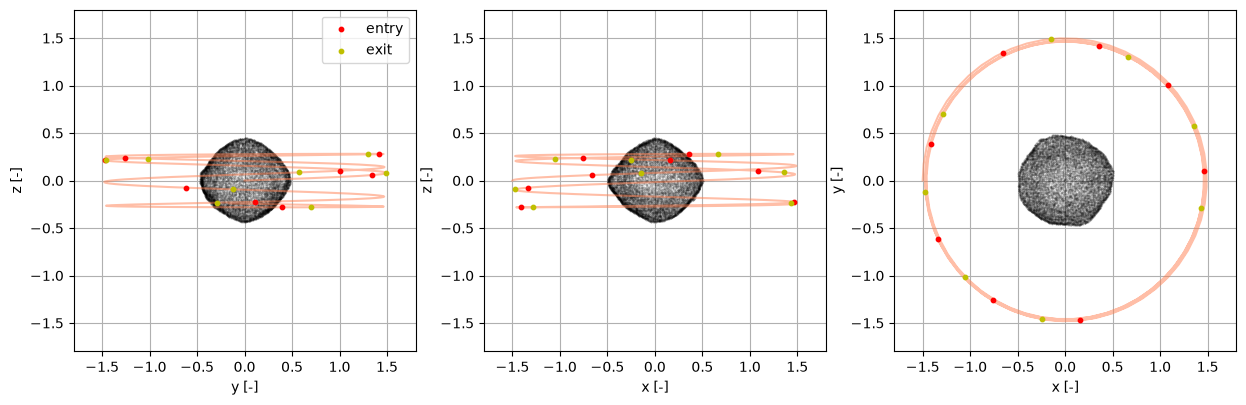

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, plane in zip(axes, ['yz', 'xz', 'xy']):
    en.plot_orbit(body, propagation, plane=plane, ax=ax)
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.8, 1.8)
axes[0].legend();

## Comparison with ray tracing

`propagate_ray_tracing` is the ground truth: it integrates the same dynamics with an adaptive Runge-Kutta scheme, running the Möller-Trumbore test at every evaluation of the dynamics to switch the radiation pressure.

Propagated in 16.8 s
Largest position error: 0.47 cm


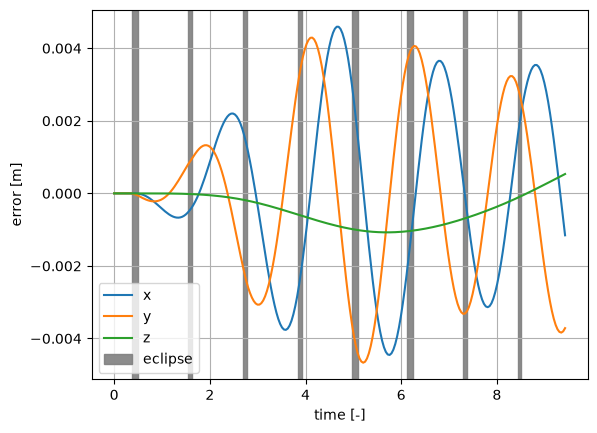

In [7]:
start = time.time()
truth = en.propagate_ray_tracing(body, ic, tgrid, sun_direction, srp=SRP)
t_ray_tracing = time.time() - start
print(f"Propagated in {t_ray_tracing:.1f} s")

errors = (propagation.states[:, :3] - truth[:, :3]) * body.L  # in meters
ax = en.plot_position_errors(tgrid, errors, propagation.eclipses)
ax.legend(loc='lower left')
print(f"Largest position error: {np.abs(errors).max() * 100:.2f} cm")

## Four bodies (Itokawa, Bennu, Eros, and 67P)

The same comparison for the four bodies: three projections of the orbit obtained with the EclipseNET as event function, with the points where the eclipses start and end, and the position error with respect to the ray-tracing propagation.

Churyumov-Gerasimenko: 9 eclipses, largest position error 0.514 m


Itokawa: 3 eclipses, largest position error 0.054 m


Bennu: 8 eclipses, largest position error 0.005 m


Eros: 4 eclipses, largest position error 0.213 m


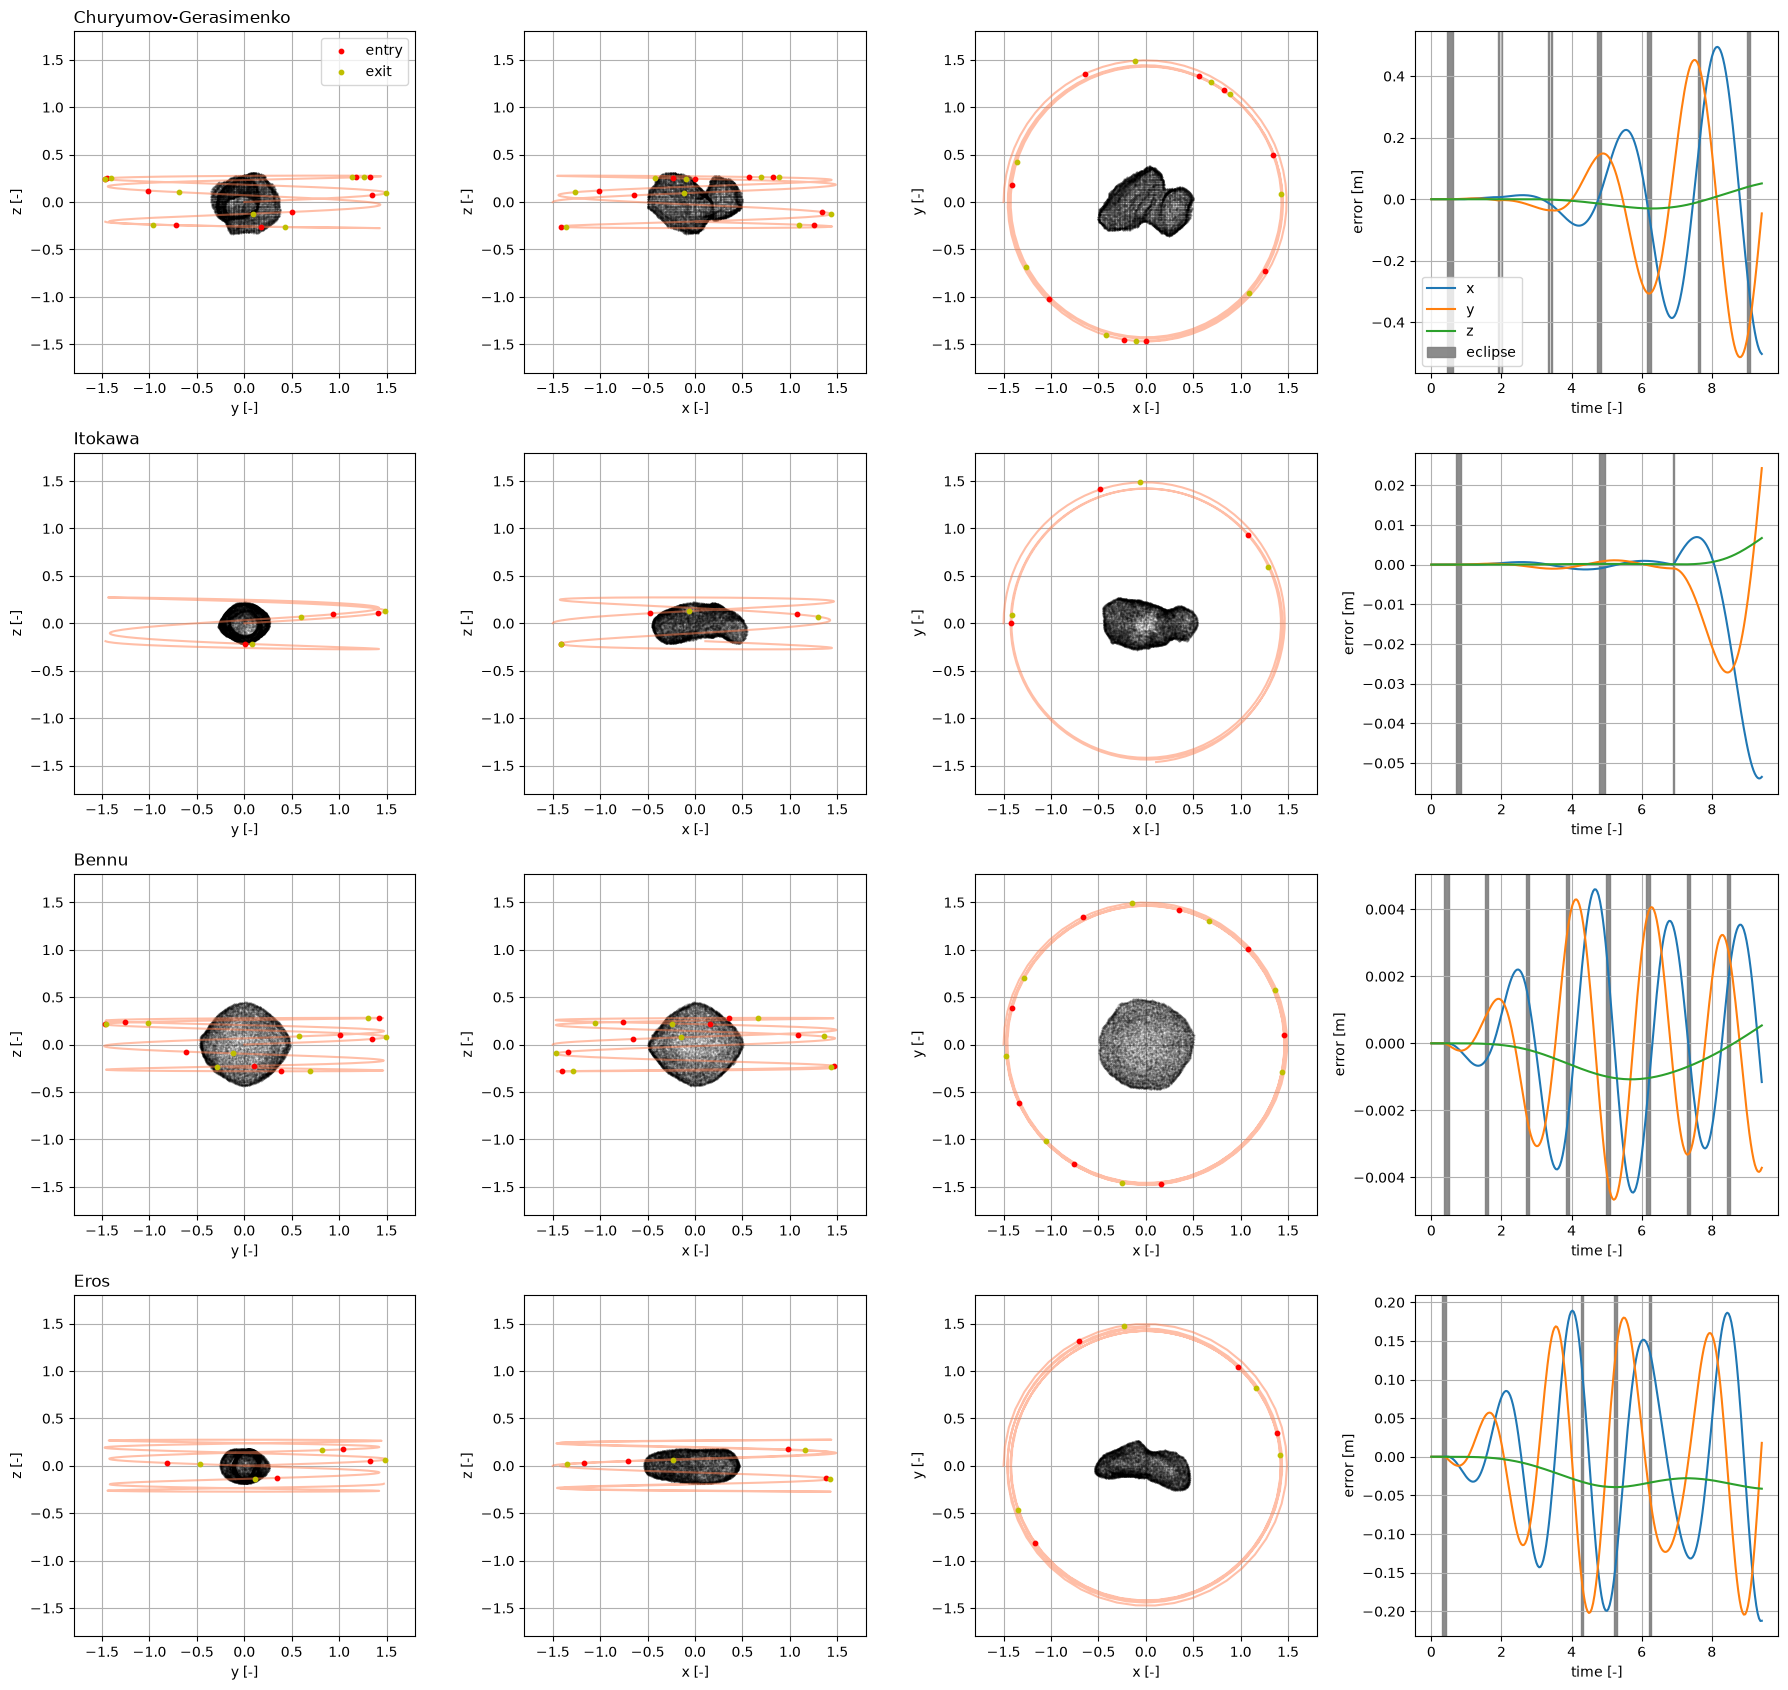

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(18, 17))
for row, name in zip(axes, ["67P", "Itokawa", "Bennu", "Eros"]):
    body = en.load_body(name)
    ic = en.initial_state(radius=1.5, inclination=np.radians(11.), omega=body.omega)
    propagation = en.EclipseNetPropagator(body, en.load_pretrained(name, "siren")).propagate(ic, tgrid, sun_direction, srp=SRP)
    truth = en.propagate_ray_tracing(body, ic, tgrid, sun_direction, srp=SRP)
    errors = (propagation.states[:, :3] - truth[:, :3]) * body.L

    for ax, plane in zip(row, ['yz', 'xz', 'xy']):
        en.plot_orbit(body, propagation, plane=plane, ax=ax)
        ax.set_xlim(-1.8, 1.8)
        ax.set_ylim(-1.8, 1.8)
    row[0].set_title(body.name, loc='left')
    en.plot_position_errors(tgrid, errors, propagation.eclipses, ax=row[3])
    print(f"{body.name}: {len(propagation.eclipses)} eclipses, largest position error {np.abs(errors).max():.3f} m")
axes[0, 0].legend()
axes[0, 3].legend(loc='lower left')
fig.tight_layout()